# Test Coding (Not Assessment)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


In [3]:
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)


In [ ]:
# Define a simple CNN model
model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation="relu"),
  layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])


In [ ]:
# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9079 - loss: 0.2991 - val_accuracy: 0.9868 - val_loss: 0.0391
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9862 - loss: 0.0439 - val_accuracy: 0.9888 - val_loss: 0.0330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9883 - val_loss: 0.0366
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9941 - loss: 0.0189 - val_accuracy: 0.9913 - val_loss: 0.0286
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9956 - loss: 0.0144 - val_accuracy: 0.9899 - val_loss: 0.0309


In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9854 - loss: 0.0402
Test accuracy: 0.9899


In [ ]:
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


# Task 1: Data Understanding and Visualization:
1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:
* Get the list of class directories from the train folder.
* Select one image randomly from each class.
* Display the images in a grid format with two rows using matplotlib.
* What did you Observe?

In [32]:
import zipfile
with zipfile.ZipFile('/content/FruitinAmazon.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/extracted_folder')


In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image


In [34]:
# Define paths
train_dir = '/content/extracted_folder/FruitinAmazon/train'
test_dir = '/content/extracted_folder/FruitinAmazon/test'

In [35]:
# Get list of class directories
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Select one random image from each class
random_images = []
class_names = []

for class_name in class_dirs:
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))  # Randomly select one image
    random_images.append(os.path.join(class_path, image_name))
    class_names.append(class_name)

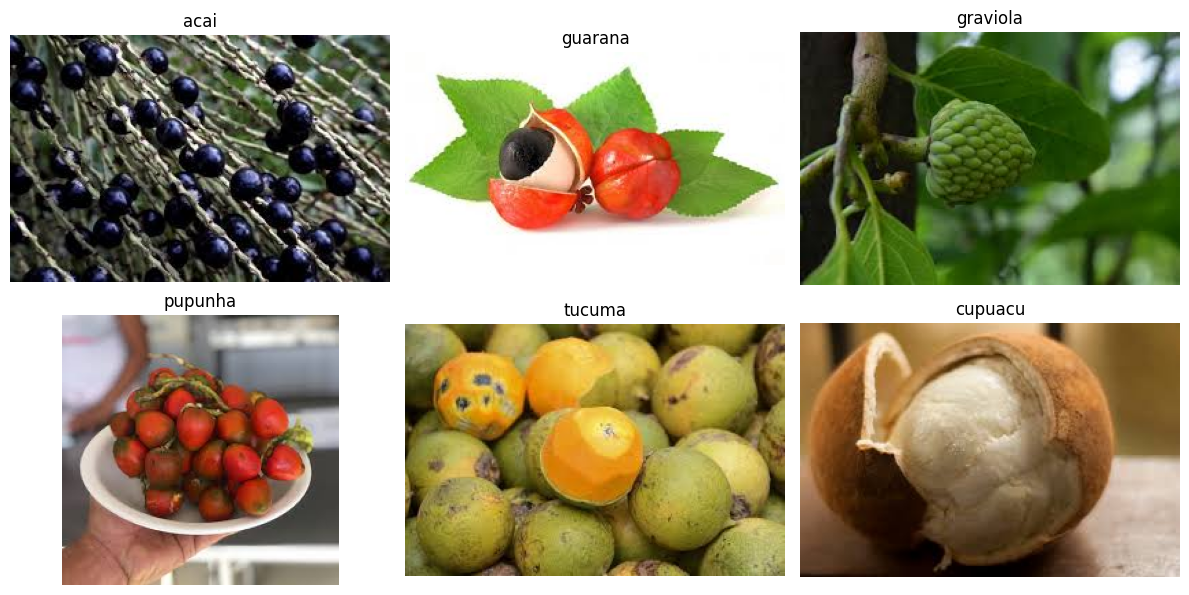

In [36]:
# Display images in a grid (2 rows)
plt.figure(figsize=(12, 6))
columns = (len(random_images) + 1) // 2
for i, img_path in enumerate(random_images):
    plt.subplot(2, columns, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”
* Hint:
 * Iterate through each class subdirectory and check if each image is valid.
 * Use the Image.open() function to attempt to load each image.
 * If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print ```f"Removed corrupted image: {image_path}"```.
 * Maintain a list of all corrupted image paths for reporting.
* Expected Output: No corrupted images found.


In [37]:

# List to store corrupted image paths
corrupted_images = []

# Iterate through class directories
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                with Image.open(image_path) as img:
                    img.verify()  # Verify the image integrity
            except (IOError, SyntaxError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")



# Final report
if corrupted_images:
    print(f"Total corrupted images removed: {len(corrupted_images)}")
else:
    print("No Corrupted Images Found.")


No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras:
``` image_dataset_from_directory function in Keras.```

This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.


In [75]:
import tensorflow as tf

# Define the path to your train directory and parameters
img_height = 128  # Desired image height
img_width = 128   # Desired image width
batch_size = 20   # Number of images per batch
validation_split = 0.2  # 20% data for validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0, 1]


In [76]:

# Load the training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',         # Automatically infer the labels from subdirectories
    label_mode='int',          # Labels as integers (could also use 'categorical' or 'binary')
    image_size=(img_height, img_width),  # Resize images to this shape
    interpolation='nearest',   # Interpolation method for resizing
    batch_size=batch_size,     # Batch size for training
    shuffle=True,              # Shuffle the data
    validation_split=validation_split,  # Split data for training and validation
    subset='training',         # Specify this is for training subset
    seed=123                   # Random seed for reproducibility
)

# Apply the normalization (Rescaling) to the training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.


In [77]:

# Load the validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',         # Automatically infer the labels from subdirectories
    label_mode='int',          # Labels as integers
    image_size=(img_height, img_width),  # Resize images
    interpolation='nearest',   # Interpolation method for resizing
    batch_size=batch_size,     # Batch size for validation
    shuffle=True,              # Shuffle the validation data
    validation_split=validation_split,  # Same validation split for validation
    subset='validation',       # Specify this is for validation subset
    seed=123                   # Random seed for reproducibility
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))



Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN

## Convolutional Architecture
- **Convolutional Layer 1:**
  - Filter Size (F): `(3, 3)`
  - Number of Filters (k): `32`
  - Padding (P): `same`
  - Stride (s): `1`
- **Activation Layer:** `ReLU activation`
- **Pooling Layer 1:**
  - Filter Size (F): `(2, 2)`
  - Stride (s): `2`

- **Convolutional Layer 2:**
  - Filter Size (F): `(3, 3)`
  - Number of Filters (k): `32`
  - Padding (P): `same`
  - Stride (s): `1`
- **Activation Layer:** `ReLU activation`
- **Pooling Layer 2:**
  - Filter Size (F): `(2, 2)`
  - Stride (s): `2`

## Fully Connected Network Architecture
- **Flatten Layer:** Flattens the input coming from the convolutional layers
- **Input Layer**
- **Hidden Layers:**  
  - First Hidden Layer - `64 neurons`  
  - Second Hidden Layer - `128 neurons`
- **Output Layer:** `num_classes` (Number of output classes)


In [78]:

# Define the model
model = keras.Sequential([
    # First Convolutional Layer
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),  # (3, 3) filter, 32 filters input_layer= 128x128 for 3 layers:R,G,B
    layers.MaxPooling2D((2, 2), strides=2),  # Max pooling with (2, 2) filter, stride 2

    # Second Convolutional Layer
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),  # (3, 3) filter, 32 filters
    layers.MaxPooling2D((2, 2), strides=2),  # Max pooling with (2, 2) filter, stride 2

    # Flatten the output to feed into dense layers
    layers.Flatten(),

    # Fully connected hidden layers
    layers.Dense(64, activation='relu'),  # Hidden layer with 64 neurons
    layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons

    # Output layer with the number of classes
    layers.Dense(6, activation='softmax')  # 6 classes for fruit types
])


In [55]:

# Print the model summary
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model
## Model Compilation
* Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).


In [79]:
# Compile the model
model.compile(
    optimizer='adam',  # Optimizer: Adam
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification with integer labels
    metrics=['accuracy']  # Evaluation metric: Accuracy
)

In [57]:
# Display the compiled model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Train the Model
## Model Training
* Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
* Use val ds for validation.
* Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.


In [58]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [80]:
# Define the callbacks
callbacks = [
    # Save the best model based on validation accuracy
    ModelCheckpoint(
        'best_model.h5',  # Path to save the best model
        save_best_only=True,  # Save only the best model
        monitor='val_loss',  # Monitor validation loss
        mode='min',  # Minimize the validation loss
        verbose=1
    ),
    # Stop training if validation loss doesn't improve for 10 epochs
    EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,  # Wait for 10 epochs before stopping
        restore_best_weights=True,  # Restore best weights after stopping
        verbose=1
    )
]

In [81]:
# Train the model
history = model.fit(
    train_ds,  # Training dataset
    validation_data=val_ds,  # Validation dataset
    epochs=250,  # Number of epochs
    batch_size=32,  # Batch size
    callbacks=callbacks  # Callbacks for early stopping and saving the best model
)


Epoch 1/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.1340 - loss: 2.9091
Epoch 1: val_loss improved from inf to 1.87329, saving model to best_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.1378 - loss: 2.9323 - val_accuracy: 0.0556 - val_loss: 1.8733
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.2062 - loss: 1.7900
Epoch 2: val_loss improved from 1.87329 to 1.84249, saving model to best_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.2067 - loss: 1.7908 - val_accuracy: 0.0556 - val_loss: 1.8425
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3424 - loss: 1.7170
Epoch 3: val_loss improved from 1.84249 to 1.82778, saving model to best_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.3544 - loss: 1.7164 - val_accuracy: 0.2222 - val_loss: 1.8278
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5576 - loss: 1.6514
Epoch 4: val_loss did not improve from 1.82778
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.5489 - loss: 1.6507 - val_accuracy: 0.1111 - val_loss: 1.8657
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.3222 - loss: 1.5666
Epoch 5: val_loss did not improve from 1.82778
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.3272 - loss: 1.5607 - val_accuracy: 0.1111 - val_loss: 1.8493
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5063 - loss: 1.3386
Epoch 6: val_loss improved from 1.82778 to 1.79159, saving model to best_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.5050 - loss: 1.3453 - val_accuracy: 0.2778 - val_loss: 1.7916
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7882 - loss: 1.1142
Epoch 7: val_loss improved from 1.79159 to 1.56196, saving model to best_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step - accuracy: 0.7861 - loss: 1.1108 - val_accuracy: 0.5000 - val_loss: 1.5620
Epoch 8/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8465 - loss: 0.8231
Epoch 8: val_loss did not improve from 1.56196
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.8411 - loss: 0.8206 - val_accuracy: 0.3333 - val_loss: 2.0531
Epoch 9/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9139 - loss: 0.5343
Epoch 9: val_loss improved from 1.56196 to 1.37748, saving model to best_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.9006 - loss: 0.5449 - val_accuracy: 0.4444 - val_loss: 1.3775
Epoch 10/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8417 - loss: 0.4299
Epoch 10: val_loss did not improve from 1.37748
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.8400 - loss: 0.4326 - val_accuracy: 0.4444 - val_loss: 2.0284
Epoch 11/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9174 - loss: 0.3686
Epoch 11: val_loss did not improve from 1.37748
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.9144 - loss: 0.3684 - val_accuracy: 0.5000 - val_loss: 1.8045
Epoch 12/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9382 - loss: 0.2255
Epoch 12: val_loss did not improve from 1.37748
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.9394 - loss: 0.2270 - val_accuracy: 0.3333 - val_loss: 2.7093
Epoch 13/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9861 - loss: 0.1674
Epoch 13: val_loss did not improve from 1.37748
4/4 

# Task 5: Evaluate the Model
## Model Evaluation
* After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.


In [82]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # No shuffling for consistent evaluation
)

# Apply the same normalization as train/val
test_ds = test_ds.map(lambda x, y: (rescale(x), y))


Found 30 files belonging to 6 classes.


In [83]:

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4944 - loss: 1.0452
Test Loss: 1.0923, Test Accuracy: 0.4667



Plotting training history (accuracy and loss)


In [84]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 12))


<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

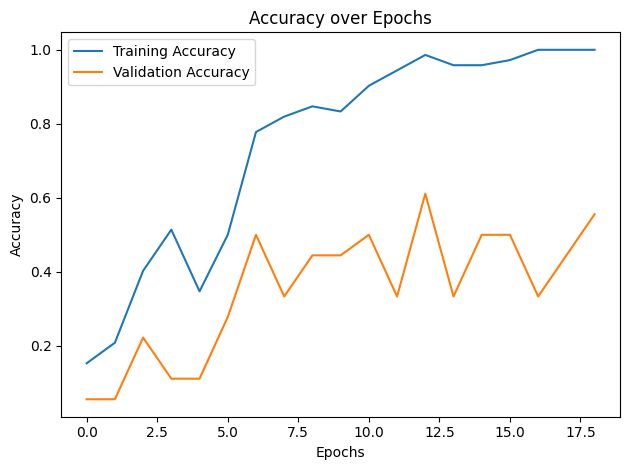

In [85]:
# Accuracy plot

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

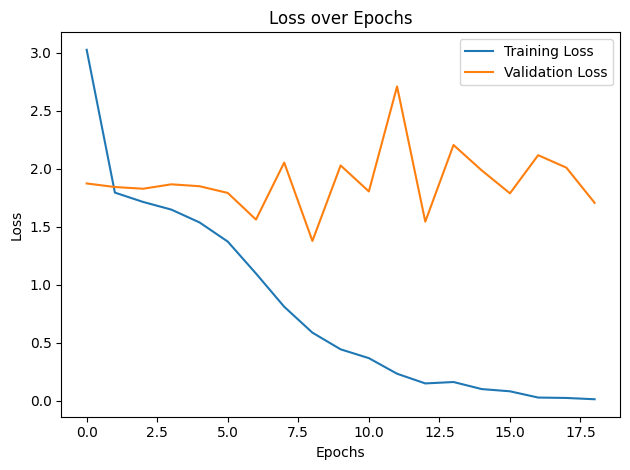

In [86]:

# Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Task 6: Save and Load the Model
## Model Saving and Loading
* Save the trained model to an .h5 file using model.save().
* Load the saved model and re-evaluate its performance on the test set.


In [87]:
# Save the trained model to an .h5 file
model.save('keraharu.h5')
print("Model saved successfully as 'keraharu.h5'")


Model saved successfully as 'keraharu.h5'


In [89]:
# Load the saved model
loaded_model = tf.keras.models.load_model('keraharu.h5')
print("Model loaded successfully.")


Model loaded successfully.


In [90]:
# Re-evaluate the loaded model
test_loss, test_accuracy = loaded_model.evaluate(test_ds)
print(f"Test Loss (Loaded Model): {test_loss:.4f}, Test Accuracy (Loaded Model): {test_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4944 - loss: 1.0452 
Test Loss (Loaded Model): 1.0923, Test Accuracy (Loaded Model): 0.4667


# Task 7: Predictions and Classification Report
## Making Predictions
* Use model.predict() to make predictions on test images.
* Convert the model’s predicted probabilities to digit labels using np.argmax().
* Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [91]:
import numpy as np
from sklearn.metrics import classification_report


In [92]:
# Predict probabilities for test data
predictions = loaded_model.predict(test_ds)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


In [93]:
# Extract true labels from the test dataset
true_labels = np.concatenate([y for x, y in test_ds], axis=0)


In [94]:
from sklearn.metrics import classification_report

# Print classification report
print(classification_report(true_labels, predicted_labels))


              precision    recall  f1-score   support

           0       0.50      0.80      0.62         5
           1       0.50      0.60      0.55         5
           2       0.75      0.60      0.67         5
           3       0.25      0.20      0.22         5
           4       0.40      0.40      0.40         5
           5       0.33      0.20      0.25         5

    accuracy                           0.47        30
   macro avg       0.46      0.47      0.45        30
weighted avg       0.46      0.47      0.45        30

